In [36]:
import numpy as np
import pandas as pd
import torch
import torchtuples as tt
import matplotlib.pyplot as plt

from pycox.preprocessing.label_transforms import LabTransDiscreteTime
from pycox.models import DeepHit
from lifelines.utils import concordance_index

# -----------------------------
# Load embeddings + outcomes
# -----------------------------
X_train_df = pd.read_csv('/home/UT_shared/data/emb_train.csv')
X_val_df   = pd.read_csv('/home/UT_shared/data/emb_val.csv')
X_test_df  = pd.read_csv('/home/UT_shared/data/emb_test.csv')

train_out = pd.read_csv('/home/UT_shared/data/train.csv')[['year','status']]
val_out   = pd.read_csv('/home/UT_shared/data/val.csv')[['year','status']]
test_out  = pd.read_csv('/home/UT_shared/data/test.csv')[['year','status']]

X_train = X_train_df.values.astype('float32')
X_val   = X_val_df.values.astype('float32')
X_test  = X_test_df.values.astype('float32')

dur_train = train_out['year'].values.astype('float32')
dur_val   = val_out['year'].values.astype('float32')
dur_test  = test_out['year'].values.astype('float32')

evt_train = train_out['status'].values.astype('int64')  # 0=censor, 1..R causes
evt_val   = val_out['status'].values.astype('int64')
evt_test  = test_out['status'].values.astype('int64')

# -----------------------------
# Discretize time (same as before)
# -----------------------------
class LabTransform(LabTransDiscreteTime):
    def transform(self, durations, events):
        durations_disc, is_event = super().transform(durations, events > 0)
        events = events.copy()
        events[is_event == 0] = 0
        return durations_disc, events.astype('int64')

num_durations = 40
labtrans = LabTransform(num_durations)
y_train = labtrans.fit_transform(dur_train, evt_train)
y_val   = labtrans.transform(dur_val, evt_val)

# -----------------------------
# Define net (same as before)
# -----------------------------
class CauseSpecificNet(torch.nn.Module):
    def __init__(self, in_features, num_nodes_shared, num_nodes_indiv, num_risks,
                 out_features, batch_norm=True, dropout=None):
        super().__init__()
        self.shared_net = tt.practical.MLPVanilla(
            in_features, num_nodes_shared[:-1], num_nodes_shared[-1],
            batch_norm, dropout,
        )
        self.risk_nets = torch.nn.ModuleList([
            tt.practical.MLPVanilla(
                num_nodes_shared[-1], num_nodes_indiv, out_features,
                batch_norm, dropout,
            ) for _ in range(num_risks)
        ])

    def forward(self, x):
        h = self.shared_net(x)
        out = [net(h) for net in self.risk_nets]
        out = torch.stack(out, dim=1)  # (batch, risks, out_features)
        return out

in_features = X_train.shape[1]
num_risks = int(max(evt_train.max(), evt_val.max(), evt_test.max()))
out_features = len(labtrans.cuts)

net = CauseSpecificNet(
    in_features=in_features,
    num_nodes_shared=[64, 64],
    num_nodes_indiv=[32],
    num_risks=num_risks,
    out_features=out_features,
    batch_norm=True,
    dropout=0.1
)

optimizer = tt.optim.AdamWR(lr=0.001, decoupled_weight_decay=0.01, cycle_eta_multiplier=0.8)
model = DeepHit(net, optimizer, alpha=0.2, sigma=0.1, duration_index=labtrans.cuts)

# -----------------------------
# Train
# -----------------------------
epochs = 50
batch_size = 256
callbacks = [tt.callbacks.EarlyStoppingCycle()]
log = model.fit(X_train, y_train, batch_size, epochs, callbacks, verbose=False, val_data=(X_val, y_val))

# -----------------------------
# Predict CIF and compute C-index curve (cause 1)
# -----------------------------
cif_pred = model.predict_cif(X_test)
cif_arr = np.asarray(cif_pred)

# fix shape to (n_times, n_samples, n_risks)
n_samples = X_test.shape[0]
if cif_arr.shape[2] == n_samples and cif_arr.shape[0] <= 10:
    cif_arr = np.transpose(cif_arr, (1, 2, 0))
elif cif_arr.shape[0] == n_samples:
    cif_arr = np.transpose(cif_arr, (1, 0, 2))

time_deephit = np.asarray(labtrans.cuts).astype(float)

cause_of_interest = 1
cause_idx = cause_of_interest - 1
event1 = (evt_test == cause_of_interest).astype(int)

cindex_deephit = np.full(len(time_deephit), np.nan, dtype=float)
for j in range(len(time_deephit)):
    risk_score = cif_arr[j, :, cause_idx]
    if event1.sum() == 0:
        break
    if np.allclose(risk_score, risk_score[0]):
        continue
    try:
        cindex_deephit[j] = concordance_index(dur_test, -risk_score, event_observed=event1)
    except Exception:
        pass

deephit_df = pd.DataFrame({"time": time_deephit, "cindex": cindex_deephit})
deephit_df.to_csv("/home/UT_shared/result/deephit_cindex_curve_emb.csv", index=False)
print("Saved DeepHit curve to /home/UT_shared/result/deephit_cindex_curve_emb.csv")

Saved DeepHit curve to /home/UT_shared/result/deephit_cindex_curve_emb.csv


In [40]:
import numpy as np
from lifelines import KaplanMeierFitter

def calc_cr_brier(times, status, pred_cif, time_grid, cause=1):
    """
    IPCW Brier score for competing risks.
    pred_cif shape: (n_times, n_samples)
    """

    n = len(times)

    # censoring KM
    cens_km = KaplanMeierFitter()
    cens_km.fit(times, event_observed=(status == 0))

    def G(t):
        return np.maximum(cens_km.predict(t), 1e-6)

    brier = np.zeros(len(time_grid))

    for j, t in enumerate(time_grid):

        pred = pred_cif[j, :]

        # truth
        outcome = ((times <= t) & (status == cause)).astype(float)

        diff_sq = (outcome - pred) ** 2

        weights = np.zeros(n)

        # observed event
        mask_event = (times <= t) & (status != 0)
        if np.any(mask_event):
            weights[mask_event] = 1 / G(times[mask_event])

        # still at risk
        mask_surv = (times > t)
        if np.any(mask_surv):
            weights[mask_surv] = 1 / G(t)

        weights[np.isinf(weights)] = 0

        brier[j] = np.mean(weights * diff_sq)

    return brier

In [41]:
cif_raw = cif_arr[:, :, 0]  # cause 1
time_raw = time_deephit

brier_raw = calc_cr_brier(
    dur_test,
    evt_test,
    cif_raw,
    time_raw,
    cause=1
)

In [43]:
import numpy as np
import pandas as pd
import torch
import torchtuples as tt
import matplotlib.pyplot as plt

from pycox.preprocessing.label_transforms import LabTransDiscreteTime
from pycox.models import DeepHit
from lifelines.utils import concordance_index

# -----------------------------
# Load raw features + outcomes
# -----------------------------
train_df = pd.read_csv('/home/UT_shared/data/train.csv')
val_df   = pd.read_csv('/home/UT_shared/data/val.csv')
test_df  = pd.read_csv('/home/UT_shared/data/test.csv')

# Features MUST exclude outcome columns
X_train = train_df.drop(columns=['year', 'status']).values.astype('float32')
X_val   = val_df.drop(columns=['year', 'status']).values.astype('float32')
X_test  = test_df.drop(columns=['year', 'status']).values.astype('float32')

# Outcomes
dur_train = train_df['year'].values.astype('float32')
dur_val   = val_df['year'].values.astype('float32')
dur_test  = test_df['year'].values.astype('float32')

evt_train = train_df['status'].values.astype('int64')   # 0=censor, 1..R causes
evt_val   = val_df['status'].values.astype('int64')
evt_test  = test_df['status'].values.astype('int64')

# -----------------------------
# Discretize time
# -----------------------------
class LabTransform(LabTransDiscreteTime):
    def transform(self, durations, events):
        durations_disc, is_event = super().transform(durations, events > 0)
        events = events.copy()
        events[is_event == 0] = 0
        return durations_disc, events.astype('int64')

num_durations = 40
labtrans = LabTransform(num_durations)
y_train = labtrans.fit_transform(dur_train, evt_train)
y_val   = labtrans.transform(dur_val, evt_val)

# -----------------------------
# Define net
# -----------------------------
class CauseSpecificNet(torch.nn.Module):
    def __init__(self, in_features, num_nodes_shared, num_nodes_indiv, num_risks,
                 out_features, batch_norm=True, dropout=None):
        super().__init__()
        self.shared_net = tt.practical.MLPVanilla(
            in_features, num_nodes_shared[:-1], num_nodes_shared[-1],
            batch_norm, dropout,
        )
        self.risk_nets = torch.nn.ModuleList([
            tt.practical.MLPVanilla(
                num_nodes_shared[-1], num_nodes_indiv, out_features,
                batch_norm, dropout,
            ) for _ in range(num_risks)
        ])

    def forward(self, x):
        h = self.shared_net(x)
        out = [net(h) for net in self.risk_nets]
        out = torch.stack(out, dim=1)  # (batch, risks, out_features)
        return out

in_features = X_train.shape[1]
num_risks = int(max(evt_train.max(), evt_val.max(), evt_test.max()))
out_features = len(labtrans.cuts)

net = CauseSpecificNet(
    in_features=in_features,
    num_nodes_shared=[64, 64],
    num_nodes_indiv=[32],
    num_risks=num_risks,
    out_features=out_features,
    batch_norm=True,
    dropout=0.1
)

optimizer = tt.optim.AdamWR(lr=0.001, decoupled_weight_decay=0.01, cycle_eta_multiplier=0.8)
model = DeepHit(net, optimizer, alpha=0.2, sigma=0.1, duration_index=labtrans.cuts)

# -----------------------------
# Train
# -----------------------------
epochs = 50
batch_size = 256
callbacks = [tt.callbacks.EarlyStoppingCycle()]
log = model.fit(X_train, y_train, batch_size, epochs, callbacks,
                verbose=False, val_data=(X_val, y_val))

# -----------------------------
# Predict CIF and compute C-index curve (cause 1)
# -----------------------------
cif_pred = model.predict_cif(X_test)
cif_arr = np.asarray(cif_pred)

# Fix shape to (n_times, n_samples, n_risks)
n_samples = X_test.shape[0]
if cif_arr.ndim != 3:
    raise ValueError(f"Unexpected CIF shape: {cif_arr.shape}")

# Common: (n_risks, n_times, n_samples)
if cif_arr.shape[2] == n_samples and cif_arr.shape[0] <= 10:
    cif_arr = np.transpose(cif_arr, (1, 2, 0))
# Alternative: (n_samples, n_times, n_risks)
elif cif_arr.shape[0] == n_samples:
    cif_arr = np.transpose(cif_arr, (1, 0, 2))

time_deephit = np.asarray(labtrans.cuts).astype(float)

cause_of_interest = 1
cause_idx = cause_of_interest - 1
event1 = (evt_test == cause_of_interest).astype(int)

cindex_deephit = np.full(len(time_deephit), np.nan, dtype=float)
for j in range(len(time_deephit)):
    risk_score = cif_arr[j, :, cause_idx]
    if event1.sum() == 0:
        break
    if np.allclose(risk_score, risk_score[0]):
        continue
    try:
        # negative to match your R convention (x = -CIF)
        cindex_deephit[j] = concordance_index(dur_test, -risk_score, event_observed=event1)
    except Exception:
        pass

deephit_df = pd.DataFrame({"time": time_deephit, "cindex": cindex_deephit})
deephit_df.to_csv("/home/UT_shared/result/deephit_cindex_curve.csv", index=False)
print("Saved DeepHit curve to /home/UT_shared/result/deephit_cindex_curve.csv")

Saved DeepHit curve to /home/UT_shared/result/deephit_cindex_curve.csv


In [44]:
cif_emb = cif_arr[:, :, 0]
time_emb = time_deephit

brier_emb = calc_cr_brier(
    dur_test,
    evt_test,
    cif_emb,
    time_emb,
    cause=1
)

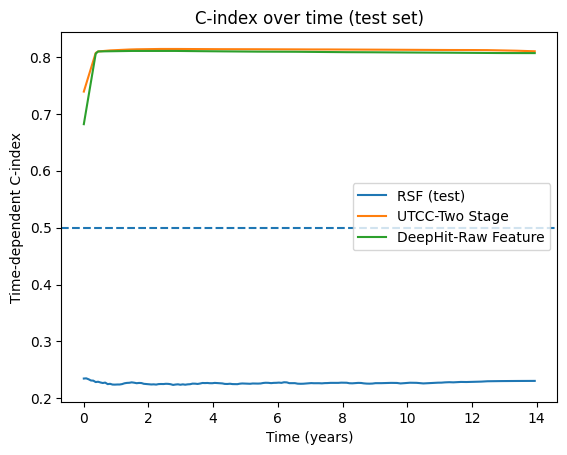

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rsf_df    = pd.read_csv("/home/UT_shared/result/rsf_cindex_curve.csv").dropna()
dh_emb_df = pd.read_csv("/home/UT_shared/result/deephit_cindex_curve_emb.csv").dropna()
dh_raw_df = pd.read_csv("/home/UT_shared/result/deephit_cindex_curve.csv").dropna()

# --- RSF grid (reference) ---
t_rsf = rsf_df["time"].values.astype(float)
c_rsf = rsf_df["cindex"].values.astype(float)

# --- DeepHit (embeddings) ---
t_dh_emb = dh_emb_df["time"].values.astype(float)
c_dh_emb = dh_emb_df["cindex"].values.astype(float)

# --- DeepHit (raw features) ---
t_dh_raw = dh_raw_df["time"].values.astype(float)
c_dh_raw = dh_raw_df["cindex"].values.astype(float)

# Ensure increasing time for interpolation
rsf_order = np.argsort(t_rsf)
t_rsf, c_rsf = t_rsf[rsf_order], c_rsf[rsf_order]

emb_order = np.argsort(t_dh_emb)
t_dh_emb, c_dh_emb = t_dh_emb[emb_order], c_dh_emb[emb_order]

raw_order = np.argsort(t_dh_raw)
t_dh_raw, c_dh_raw = t_dh_raw[raw_order], c_dh_raw[raw_order]

# --- Only interpolate where ALL three have support (common overlap) ---
tmin = max(t_rsf.min(), t_dh_emb.min(), t_dh_raw.min())
tmax = min(t_rsf.max(), t_dh_emb.max(), t_dh_raw.max())
mask = (t_rsf >= tmin) & (t_rsf <= tmax)

# Interpolate both DeepHit curves onto RSF time grid
c_dh_emb_on_rsf = np.interp(t_rsf[mask], t_dh_emb, c_dh_emb)
c_dh_raw_on_rsf = np.interp(t_rsf[mask], t_dh_raw, c_dh_raw)

# --- Plot ---
plt.figure()
plt.plot(t_rsf, c_rsf, label="RSF")
plt.plot(t_rsf[mask], c_dh_emb_on_rsf, label="UTCC-Two Stage")
plt.plot(t_rsf[mask], c_dh_raw_on_rsf, label="DeepHit-Raw Feature")

plt.axhline(0.5, linestyle="--")
plt.xlabel("Time (years)")
plt.ylabel("Time-dependent C-index")
plt.title("C-index over time (test set)")
#plt.legend(loc = "upper right")
plt.legend()
plt.show()

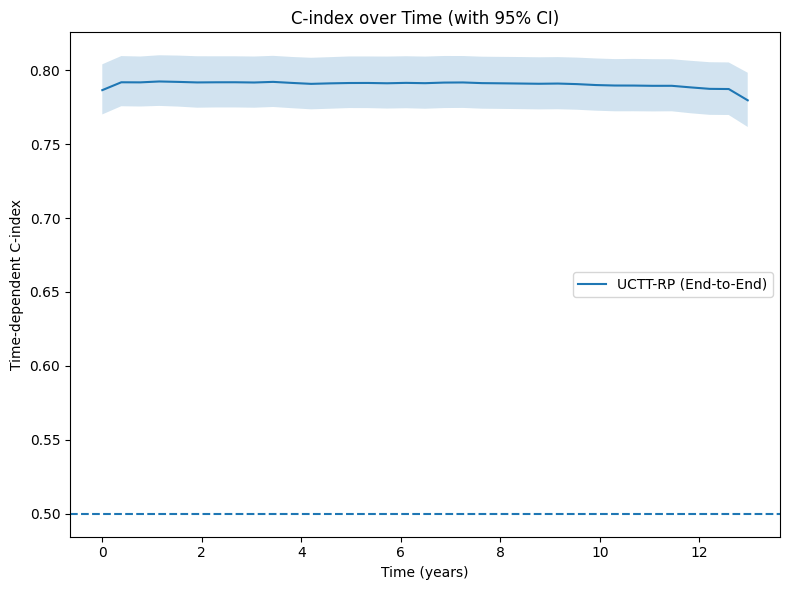

<Figure size 640x480 with 0 Axes>

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. LOAD BOOTSTRAP RESULTS
# ==========================================
tab_deephit_df = pd.read_csv(
    "/home/UT_shared/result/boot_tab_deephit_cindex_dur_40.csv"
).dropna()

# Ensure correct types
tab_deephit_df["time"] = tab_deephit_df["time"].astype(float)
tab_deephit_df["c_index"] = tab_deephit_df["c_index"].astype(float)

# Sort
tab_deephit_df = tab_deephit_df.sort_values(["time", "bootstrap"])

# ==========================================
# 2. COMPUTE MEAN + 95% CI
# ==========================================
grouped = tab_deephit_df.groupby("time")

mean_c = grouped["c_index"].mean()
lower_c = grouped["c_index"].quantile(0.025)
upper_c = grouped["c_index"].quantile(0.975)

# Convert to arrays
t_tab = mean_c.index.values.astype(float)
c_tab_mean = mean_c.values
c_tab_lower = lower_c.values
c_tab_upper = upper_c.values

# Sort by time (important for plotting)
order = np.argsort(t_tab)
t_tab = t_tab[order]
c_tab_mean = c_tab_mean[order]
c_tab_lower = c_tab_lower[order]
c_tab_upper = c_tab_upper[order]

# ==========================================
# 3. PLOT (ONLY PROPOSED METHOD)
# ==========================================
valid_max_time = 13

mask = t_tab <= valid_max_time
plt.figure(figsize=(8, 6))

plt.plot(t_tab[mask], c_tab_mean[mask], label = "UCTT-RP (End-to-End)")
plt.fill_between(
    t_tab[mask],
    c_tab_lower[mask],
    c_tab_upper[mask],
    alpha=0.2
)

# Reference line
plt.axhline(0.5, linestyle="--")

plt.xlabel("Time (years)")
plt.ylabel("Time-dependent C-index")
plt.title("C-index over Time (with 95% CI)")
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig("/home/yu10-shi/tab_deephit_cindex_ci.png", dpi=300)

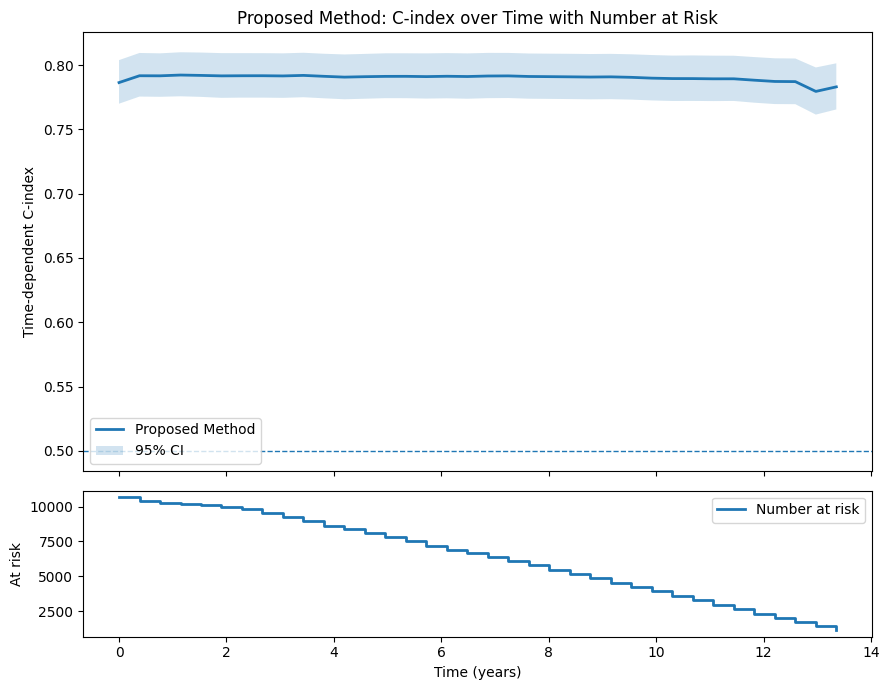

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. LOAD BOOTSTRAP C-INDEX RESULTS
# ==========================================
tab_deephit_df = pd.read_csv(
    "/home/UT_shared/result/boot_tab_deephit_cindex_dur_40.csv"
).dropna()

tab_deephit_df["time"] = tab_deephit_df["time"].astype(float)
tab_deephit_df["c_index"] = tab_deephit_df["c_index"].astype(float)
tab_deephit_df = tab_deephit_df.sort_values(["time", "bootstrap"])

# Mean + 95% CI by time
grouped = tab_deephit_df.groupby("time")
mean_c = grouped["c_index"].mean()
lower_c = grouped["c_index"].quantile(0.025)
upper_c = grouped["c_index"].quantile(0.975)

t_tab = mean_c.index.values.astype(float)
c_tab_mean = mean_c.values
c_tab_lower = lower_c.values
c_tab_upper = upper_c.values

order = np.argsort(t_tab)
t_tab = t_tab[order]
c_tab_mean = c_tab_mean[order]
c_tab_lower = c_tab_lower[order]
c_tab_upper = c_tab_upper[order]

# ==========================================
# 2. LOAD TEST DATA FOR NUMBER-AT-RISK
# ==========================================
df_test = pd.read_csv("/home/UT_shared/data/test.csv")

# Adjust this if your event indicator column has a different name
# Here we assume:
#   year   = follow-up/event time
#   status = event indicator
time_col = "year"
status_col = "status"

# Use the same time grid as the c-index curve
# Number at risk at time t = count with observed time >= t
n_at_risk = np.array([(df_test[time_col] >= t).sum() for t in t_tab])

# Optional: number of cumulative events by time t
n_events = np.array([
    ((df_test[time_col] <= t) & (df_test[status_col] == 1)).sum()
    for t in t_tab
])

# ==========================================
# 3. OPTIONAL: TRUNCATE TO STABLE REGION
# ==========================================
# Example rule: only show times with at least 1000 at risk
min_at_risk = 1000
mask_valid = n_at_risk >= min_at_risk

t_plot = t_tab[mask_valid]
c_plot = c_tab_mean[mask_valid]
l_plot = c_tab_lower[mask_valid]
u_plot = c_tab_upper[mask_valid]
risk_plot = n_at_risk[mask_valid]
events_plot = n_events[mask_valid]

# ==========================================
# 4. TWO-PANEL PLOT
# ==========================================
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(9, 7),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

# ---- Top: C-index with CI ----
ax1.plot(t_plot, c_plot, linewidth=2, label="Proposed Method")
ax1.fill_between(t_plot, l_plot, u_plot, alpha=0.2, label="95% CI")
ax1.axhline(0.5, linestyle="--", linewidth=1)

ax1.set_ylabel("Time-dependent C-index")
ax1.set_title("Proposed Method: C-index over Time with Number at Risk")
ax1.legend(loc="lower left")

# ---- Bottom: Number at risk ----
ax2.step(t_plot, risk_plot, where="post", linewidth=2, label="Number at risk")
ax2.set_xlabel("Time (years)")
ax2.set_ylabel("At risk")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

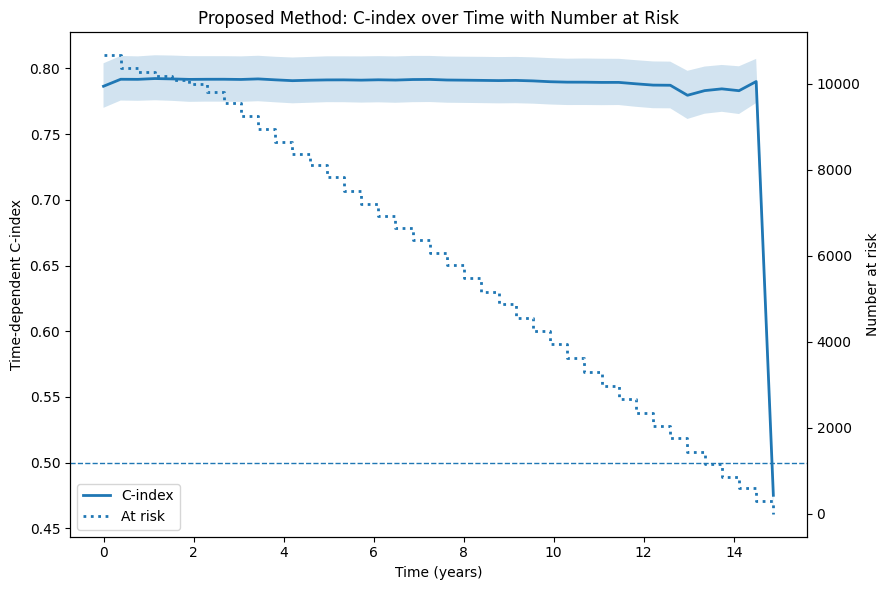

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

tab_deephit_df = pd.read_csv(
    "/home/UT_shared/result/boot_tab_deephit_cindex_dur_40.csv"
).dropna()

tab_deephit_df["time"] = tab_deephit_df["time"].astype(float)
tab_deephit_df["c_index"] = tab_deephit_df["c_index"].astype(float)
tab_deephit_df = tab_deephit_df.sort_values(["time", "bootstrap"])

grouped = tab_deephit_df.groupby("time")
mean_c = grouped["c_index"].mean()
lower_c = grouped["c_index"].quantile(0.025)
upper_c = grouped["c_index"].quantile(0.975)

t_tab = mean_c.index.values.astype(float)
c_tab_mean = mean_c.values
c_tab_lower = lower_c.values
c_tab_upper = upper_c.values

order = np.argsort(t_tab)
t_tab = t_tab[order]
c_tab_mean = c_tab_mean[order]
c_tab_lower = c_tab_lower[order]
c_tab_upper = c_tab_upper[order]

df_test = pd.read_csv("/home/UT_shared/data/test.csv")
n_at_risk = np.array([(df_test["year"] >= t).sum() for t in t_tab])

fig, ax1 = plt.subplots(figsize=(9, 6))

ax1.plot(t_tab, c_tab_mean, linewidth=2, label="C-index")
ax1.fill_between(t_tab, c_tab_lower, c_tab_upper, alpha=0.2)
ax1.axhline(0.5, linestyle="--", linewidth=1)
ax1.set_xlabel("Time (years)")
ax1.set_ylabel("Time-dependent C-index")
ax1.set_title("Proposed Method: C-index over Time with Number at Risk")

ax2 = ax1.twinx()
ax2.step(t_tab, n_at_risk, where="post", linewidth=2, linestyle=":", label="At risk")
ax2.set_ylabel("Number at risk")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower left")

plt.tight_layout()
plt.show()

/tmp/ipykernel_865/1558574151.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(c_tab_mean[:i+1], t_tab[:i+1])


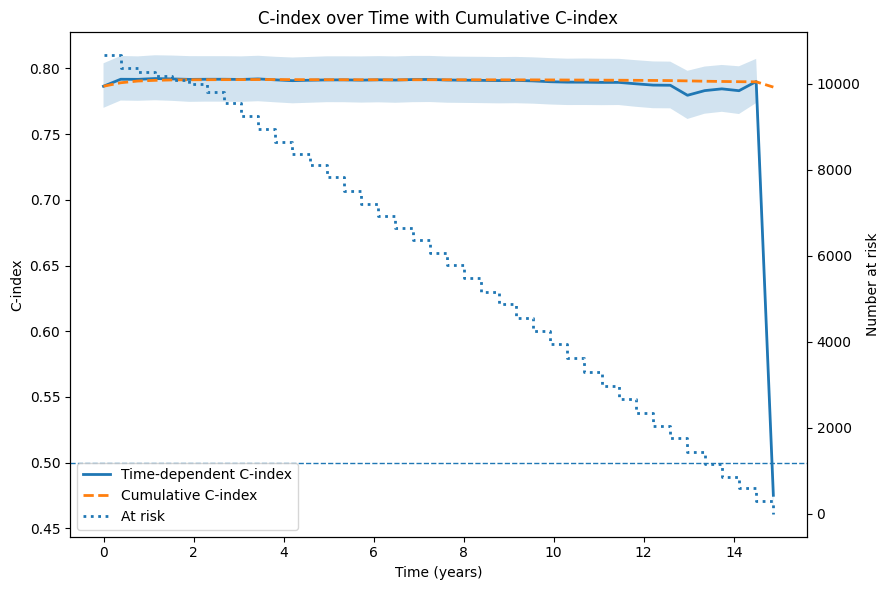

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. LOAD DATA
# ==========================================
tab_deephit_df = pd.read_csv(
    "/home/UT_shared/result/boot_tab_deephit_cindex_dur_40.csv"
).dropna()

tab_deephit_df["time"] = tab_deephit_df["time"].astype(float)
tab_deephit_df["c_index"] = tab_deephit_df["c_index"].astype(float)
tab_deephit_df = tab_deephit_df.sort_values(["time", "bootstrap"])

# ==========================================
# 2. MEAN + CI
# ==========================================
grouped = tab_deephit_df.groupby("time")
mean_c = grouped["c_index"].mean()
lower_c = grouped["c_index"].quantile(0.025)
upper_c = grouped["c_index"].quantile(0.975)

t_tab = mean_c.index.values.astype(float)
c_tab_mean = mean_c.values
c_tab_lower = lower_c.values
c_tab_upper = upper_c.values

# Sort
order = np.argsort(t_tab)
t_tab = t_tab[order]
c_tab_mean = c_tab_mean[order]
c_tab_lower = c_tab_lower[order]
c_tab_upper = c_tab_upper[order]

# ==========================================
# 3. >>> ADD THIS: cumulative C-index
# ==========================================
cum_cindex = np.full_like(c_tab_mean, np.nan, dtype=float)

for i in range(len(t_tab)):
    if t_tab[i] == 0:
        cum_cindex[i] = c_tab_mean[i]
    else:
        area = np.trapz(c_tab_mean[:i+1], t_tab[:i+1])
        cum_cindex[i] = area / t_tab[i]

# ==========================================
# 4. NUMBER AT RISK
# ==========================================
df_test = pd.read_csv("/home/UT_shared/data/test.csv")
n_at_risk = np.array([(df_test["year"] >= t).sum() for t in t_tab])

# ==========================================
# 5. PLOT
# ==========================================
fig, ax1 = plt.subplots(figsize=(9, 6))

# Time-dependent C-index
ax1.plot(t_tab, c_tab_mean, linewidth=2, label="Time-dependent C-index")
ax1.fill_between(t_tab, c_tab_lower, c_tab_upper, alpha=0.2)

# >>> ADD THIS LINE (cumulative)
ax1.plot(
    t_tab,
    cum_cindex,
    linewidth=2,
    linestyle="--",
    label="Cumulative C-index"
)

ax1.axhline(0.5, linestyle="--", linewidth=1)
ax1.set_xlabel("Time (years)")
ax1.set_ylabel("C-index")
ax1.set_title("C-index over Time with Cumulative C-index")

# Secondary axis
ax2 = ax1.twinx()
ax2.step(t_tab, n_at_risk, where="post", linewidth=2, linestyle=":", label="At risk")
ax2.set_ylabel("Number at risk")

# Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower left")

plt.tight_layout()
plt.show()

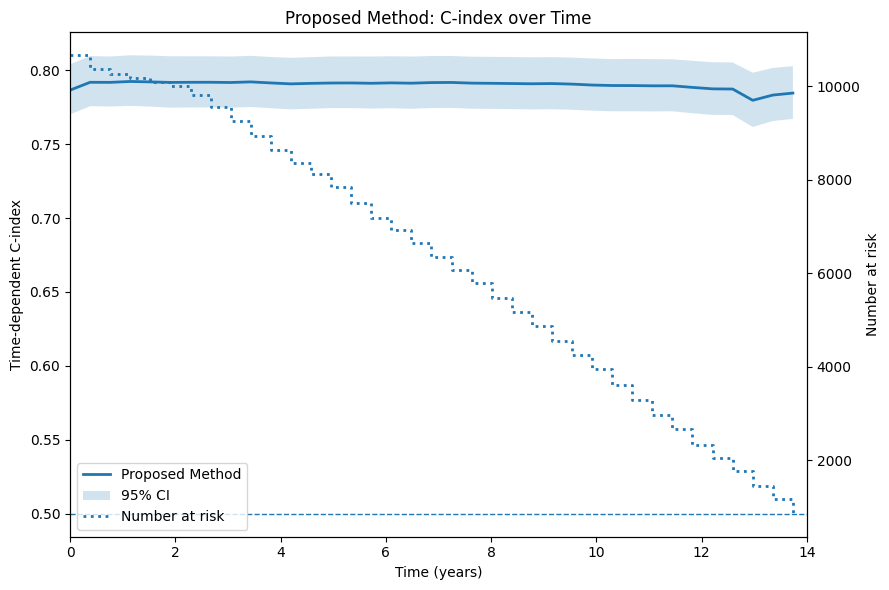

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. LOAD BOOTSTRAP C-INDEX RESULTS
# ==========================================
tab_deephit_df = pd.read_csv(
    "/home/UT_shared/result/boot_tab_deephit_cindex_dur_40.csv"
).dropna()

tab_deephit_df["time"] = tab_deephit_df["time"].astype(float)
tab_deephit_df["c_index"] = tab_deephit_df["c_index"].astype(float)
tab_deephit_df = tab_deephit_df.sort_values(["time", "bootstrap"])

# Mean + 95% CI by time
grouped = tab_deephit_df.groupby("time")
mean_c = grouped["c_index"].mean()
lower_c = grouped["c_index"].quantile(0.025)
upper_c = grouped["c_index"].quantile(0.975)

t_tab = mean_c.index.values.astype(float)
c_tab_mean = mean_c.values
c_tab_lower = lower_c.values
c_tab_upper = upper_c.values

# Sort by time
order = np.argsort(t_tab)
t_tab = t_tab[order]
c_tab_mean = c_tab_mean[order]
c_tab_lower = c_tab_lower[order]
c_tab_upper = c_tab_upper[order]

# ==========================================
# 2. LOAD TEST DATA FOR NUMBER AT RISK
# ==========================================
df_test = pd.read_csv("/home/UT_shared/data/test.csv")

time_col = "year"
status_col = "status"  # kept here in case you want event counts later

# Compute number at risk on the same time grid
n_at_risk = np.array([(df_test[time_col] >= t).sum() for t in t_tab])

# ==========================================
# 3. RESTRICT TO X RANGE <= 14
# ==========================================
max_time = 14
mask = t_tab <= max_time

t_plot = t_tab[mask]
c_plot = c_tab_mean[mask]
l_plot = c_tab_lower[mask]
u_plot = c_tab_upper[mask]
risk_plot = n_at_risk[mask]

# ==========================================
# 4. ONE-PANEL PLOT WITH SECOND Y-AXIS
# ==========================================
fig, ax1 = plt.subplots(figsize=(9, 6))

# C-index mean + CI
ax1.plot(t_plot, c_plot, linewidth=2, label="Proposed Method")
ax1.fill_between(t_plot, l_plot, u_plot, alpha=0.2, label="95% CI")
ax1.axhline(0.5, linestyle="--", linewidth=1)

ax1.set_xlabel("Time (years)")
ax1.set_ylabel("Time-dependent C-index")
ax1.set_title("Proposed Method: C-index over Time")
ax1.set_xlim(0, 14)

# Number at risk on secondary axis
ax2 = ax1.twinx()
ax2.step(t_plot, risk_plot, where="post", linestyle=":", linewidth=2, label="Number at risk")
ax2.set_ylabel("Number at risk")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower left")

plt.tight_layout()
plt.show()

/tmp/ipykernel_865/970457112.py:47: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(c_tab_mean[:i+1], t_tab[:i+1])


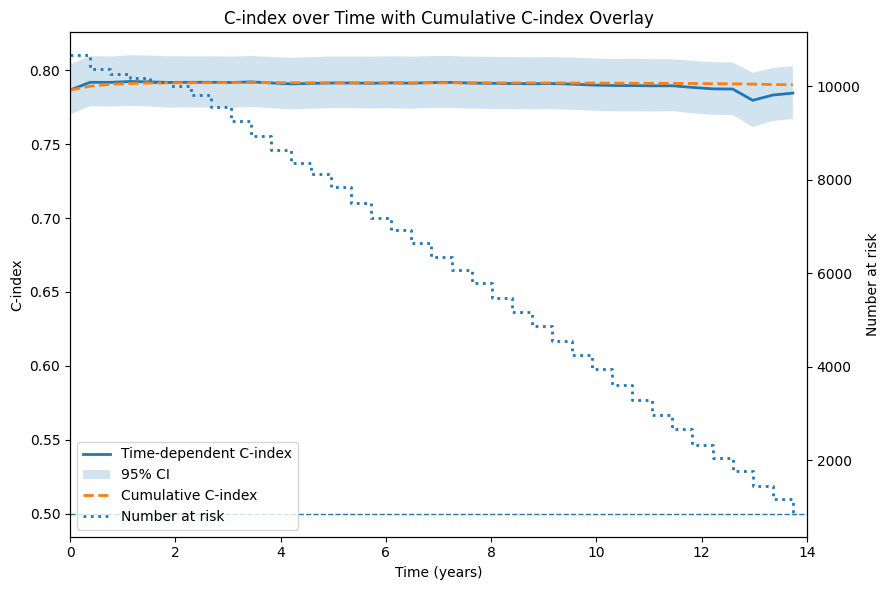

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. LOAD BOOTSTRAP C-INDEX RESULTS
# ==========================================
tab_deephit_df = pd.read_csv(
    "/home/UT_shared/result/boot_tab_deephit_cindex_dur_40.csv"
).dropna()

tab_deephit_df["time"] = tab_deephit_df["time"].astype(float)
tab_deephit_df["c_index"] = tab_deephit_df["c_index"].astype(float)
tab_deephit_df = tab_deephit_df.sort_values(["time", "bootstrap"])

# ==========================================
# 2. MEAN + 95% CI OF TIME-DEPENDENT C-INDEX
# ==========================================
grouped = tab_deephit_df.groupby("time")
mean_c = grouped["c_index"].mean()
lower_c = grouped["c_index"].quantile(0.025)
upper_c = grouped["c_index"].quantile(0.975)

t_tab = mean_c.index.values.astype(float)
c_tab_mean = mean_c.values
c_tab_lower = lower_c.values
c_tab_upper = upper_c.values

# Sort by time
order = np.argsort(t_tab)
t_tab = t_tab[order]
c_tab_mean = c_tab_mean[order]
c_tab_lower = c_tab_lower[order]
c_tab_upper = c_tab_upper[order]

# ==========================================
# 3. COMPUTE CUMULATIVE C-INDEX
# ==========================================
# Time-weighted running average using trapezoidal integration:
# cum_cindex(t_i) = integral_0^{t_i} C(u) du / t_i
cum_cindex = np.full_like(c_tab_mean, np.nan, dtype=float)

for i in range(len(t_tab)):
    if t_tab[i] == 0:
        cum_cindex[i] = c_tab_mean[i]
    else:
        area = np.trapz(c_tab_mean[:i+1], t_tab[:i+1])
        cum_cindex[i] = area / t_tab[i]

# ==========================================
# 4. LOAD TEST DATA FOR NUMBER AT RISK
# ==========================================
df_test = pd.read_csv("/home/UT_shared/data/test.csv")
time_col = "year"

n_at_risk = np.array([(df_test[time_col] >= t).sum() for t in t_tab])

# ==========================================
# 5. RESTRICT TO X RANGE <= 14
# ==========================================
max_time = 14
mask = t_tab <= max_time

t_plot = t_tab[mask]
c_plot = c_tab_mean[mask]
l_plot = c_tab_lower[mask]
u_plot = c_tab_upper[mask]
cum_plot = cum_cindex[mask]
risk_plot = n_at_risk[mask]

# ==========================================
# 6. ONE-PANEL PLOT
# ==========================================
fig, ax1 = plt.subplots(figsize=(9, 6))

# Time-dependent C-index
ax1.plot(t_plot, c_plot, linewidth=2, label="Time-dependent C-index")
ax1.fill_between(t_plot, l_plot, u_plot, alpha=0.2, label="95% CI")

# Cumulative C-index
ax1.plot(t_plot, cum_plot, linewidth=2, linestyle="--", label="Cumulative C-index")

# Reference line
ax1.axhline(0.5, linestyle="--", linewidth=1)

ax1.set_xlabel("Time (years)")
ax1.set_ylabel("C-index")
ax1.set_title("C-index over Time with Cumulative C-index Overlay")
ax1.set_xlim(0, 14)

# Secondary axis: Number at risk
ax2 = ax1.twinx()
ax2.step(t_plot, risk_plot, where="post", linestyle=":", linewidth=2, label="Number at risk")
ax2.set_ylabel("Number at risk")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower left")

plt.tight_layout()
plt.show()

t=0: at risk=10665, events=0
t=1: at risk=10208, events=172
t=2: at risk=9967, events=248
t=3: at risk=9291, events=311
t=4: at risk=8514, events=385
t=5: at risk=7811, events=443
t=6: at risk=7000, events=491
t=7: at risk=6260, events=523
t=8: at risk=5493, events=560
t=9: at risk=4702, events=593
t=10: at risk=3873, events=612
t=11: at risk=3026, events=637
t=12: at risk=2212, events=655
t=13: at risk=1429, events=663
t=14: at risk=679, events=664
t=15: at risk=0, events=664


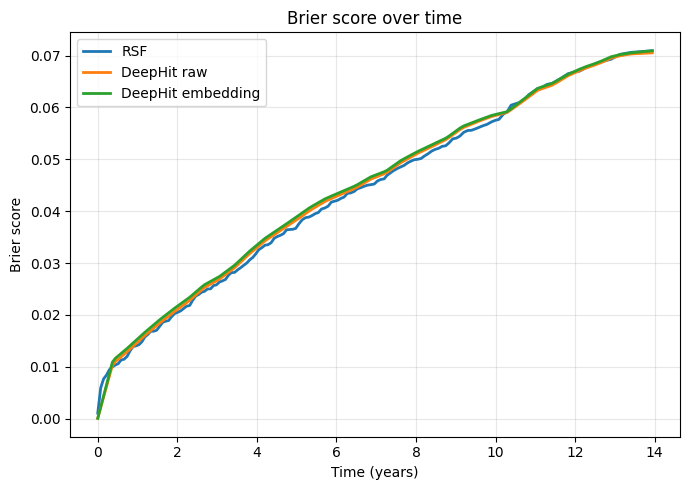

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===== 1. Load RSF Brier curve =====
rsf_brier = pd.read_csv("/home/UT_shared/result/rsf_brier_curve.csv").dropna()

# Ensure sorted by time
rsf_brier = rsf_brier.sort_values("time")

rsf_time  = rsf_brier["time"].values.astype(float)
brier_rsf = rsf_brier["bs"].values.astype(float)

# ===== 2. DeepHit results (assume already loaded) =====
# time_raw, brier_raw
# time_emb, brier_emb

# ===== 3. Define overlap time region =====
tmin = max(rsf_time.min(), time_raw.min(), time_emb.min())
tmax = min(rsf_time.max(), time_raw.max(), time_emb.max())

mask = (rsf_time >= tmin) & (rsf_time <= tmax)

# ===== 4. Interpolate DeepHit Brier scores to RSF grid =====
brier_raw_interp = np.interp(rsf_time[mask], time_raw, brier_raw)
brier_emb_interp = np.interp(rsf_time[mask], time_emb, brier_emb)

# ===== 5. Plot =====
plt.figure(figsize=(7, 5))

plt.plot(rsf_time, brier_rsf, label="RSF", linewidth=2)
plt.plot(rsf_time[mask], brier_raw_interp, label="DeepHit raw", linewidth=2)
plt.plot(rsf_time[mask], brier_emb_interp, label="DeepHit embedding", linewidth=2)

plt.xlabel("Time (years)")
plt.ylabel("Brier score")
plt.title("Brier score over time")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [16]:
print(df_train['year'].describe())

count    74655.000000
mean         8.024825
std          4.040815
min          0.002740
25%          4.753425
50%          8.156164
75%         11.441096
max         14.879452
Name: year, dtype: float64


In [17]:
print(labtrans.cuts)

[ 0.          1.35267746  2.70535492  4.05803238  5.41070984  6.7633873
  8.11606476  9.46874222 10.82141968 12.17409714 13.5267746  14.87945205]


In [ ]:
def plot_single_comparison(method_data_dict, time_grid, title, ylabel):
    plt.figure(figsize=(10, 6))
    
    for method_name, scores in method_data_dict.items():
        # Plot the single performance line
        plt.plot(time_grid, scores, label=method_name, lw=2, marker='o')

    plt.title(title, fontsize=14)
    plt.xlabel('Time (Years)', fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    
    # Add a reference line for C-index
    if "C-Index" in title:
        plt.axhline(0.5, color='grey', linestyle='--', alpha=0.5, label='Random (0.5)')
        plt.ylim(0.4, 1.0)
    
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.show()

# Example: Plotting DeepHit and Two-Stage results together
# (Assuming you've loaded both _single.npy files)
methods = {
    "DeepHit": c_index_t,
    "UTCC-Two Stage": c_index_t_2stage  # Load your other method's array here
}

plot_single_comparison(methods, time_grid, "C-Index Comparison", "Concordance Index")

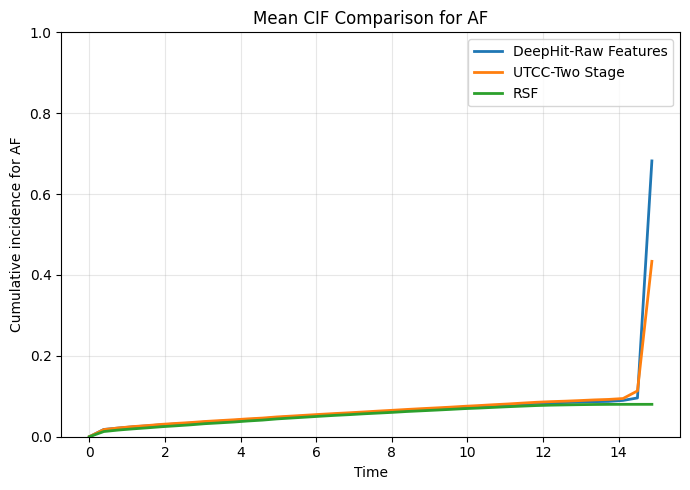

Saved combined CIF plot to /home/UT_shared/result/deephit_two_methods_mean_cif.png


In [3]:
### CIF plot
#!pip install pycox
import numpy as np
import pandas as pd
import torch
import torchtuples as tt
import matplotlib.pyplot as plt

from pycox.preprocessing.label_transforms import LabTransDiscreteTime
from pycox.models import DeepHit

# =====================================================
# 1. Load outcomes once
# =====================================================
train_out = pd.read_csv('/home/UT_shared/data/train.csv')[['year', 'status']]
val_out   = pd.read_csv('/home/UT_shared/data/val.csv')[['year', 'status']]
test_out  = pd.read_csv('/home/UT_shared/data/test.csv')[['year', 'status']]

dur_train = train_out['year'].values.astype('float32')
dur_val   = val_out['year'].values.astype('float32')
dur_test  = test_out['year'].values.astype('float32')

evt_train = train_out['status'].values.astype('int64')   # 0=censor, 1..R causes
evt_val   = val_out['status'].values.astype('int64')
evt_test  = test_out['status'].values.astype('int64')

# =====================================================
# 2. Load raw features
# =====================================================
raw_train_df = pd.read_csv('/home/UT_shared/data/train.csv')
raw_val_df   = pd.read_csv('/home/UT_shared/data/val.csv')
raw_test_df  = pd.read_csv('/home/UT_shared/data/test.csv')

X_train_raw = raw_train_df.drop(columns=['year', 'status']).values.astype('float32')
X_val_raw   = raw_val_df.drop(columns=['year', 'status']).values.astype('float32')
X_test_raw  = raw_test_df.drop(columns=['year', 'status']).values.astype('float32')

# =====================================================
# 3. Load embedding features
# =====================================================
emb_train_df = pd.read_csv('/home/UT_shared/data/emb_train.csv')
emb_val_df   = pd.read_csv('/home/UT_shared/data/emb_val.csv')
emb_test_df  = pd.read_csv('/home/UT_shared/data/emb_test.csv')

X_train_emb = emb_train_df.values.astype('float32')
X_val_emb   = emb_val_df.values.astype('float32')
X_test_emb  = emb_test_df.values.astype('float32')

# =====================================================
# 4. Discretize time
# =====================================================
class LabTransform(LabTransDiscreteTime):
    def transform(self, durations, events):
        durations_disc, is_event = super().transform(durations, events > 0)
        events = events.copy()
        events[is_event == 0] = 0
        return durations_disc, events.astype('int64')

num_durations = 40
labtrans = LabTransform(num_durations)
y_train = labtrans.fit_transform(dur_train, evt_train)
y_val   = labtrans.transform(dur_val, evt_val)

time_grid = np.asarray(labtrans.cuts).astype(float)
num_risks = int(max(evt_train.max(), evt_val.max(), evt_test.max()))
out_features = len(labtrans.cuts)

# =====================================================
# 5. Define network
# =====================================================
class CauseSpecificNet(torch.nn.Module):
    def __init__(self, in_features, num_nodes_shared, num_nodes_indiv, num_risks,
                 out_features, batch_norm=True, dropout=None):
        super().__init__()
        self.shared_net = tt.practical.MLPVanilla(
            in_features, num_nodes_shared[:-1], num_nodes_shared[-1],
            batch_norm, dropout
        )
        self.risk_nets = torch.nn.ModuleList([
            tt.practical.MLPVanilla(
                num_nodes_shared[-1], num_nodes_indiv, out_features,
                batch_norm, dropout
            ) for _ in range(num_risks)
        ])

    def forward(self, x):
        h = self.shared_net(x)
        out = [net(h) for net in self.risk_nets]
        out = torch.stack(out, dim=1)  # (batch, risks, out_features)
        return out

# =====================================================
# 6. Helper: train DeepHit and return mean CIF
# =====================================================
def train_and_get_mean_cif(X_train, X_val, X_test, y_train, y_val,
                           labtrans, num_risks, out_features,
                           epochs=50, batch_size=256, seed=1234):
    torch.manual_seed(seed)
    np.random.seed(seed)

    in_features = X_train.shape[1]

    net = CauseSpecificNet(
        in_features=in_features,
        num_nodes_shared=[64, 64],
        num_nodes_indiv=[32],
        num_risks=num_risks,
        out_features=out_features,
        batch_norm=True,
        dropout=0.1
    )

    optimizer = tt.optim.AdamWR(
        lr=0.001,
        decoupled_weight_decay=0.01,
        cycle_eta_multiplier=0.8
    )

    model = DeepHit(
        net,
        optimizer,
        alpha=0.2,
        sigma=0.1,
        duration_index=labtrans.cuts
    )

    callbacks = [tt.callbacks.EarlyStoppingCycle()]
    model.fit(
        X_train, y_train, batch_size, epochs, callbacks,
        verbose=False, val_data=(X_val, y_val)
    )

    cif_pred = model.predict_cif(X_test)
    cif_arr = np.asarray(cif_pred)

    n_samples = X_test.shape[0]
    n_times = len(labtrans.cuts)

    if cif_arr.ndim != 3:
        raise ValueError(f"Unexpected CIF shape: {cif_arr.shape}")

    # Convert to (n_times, n_samples, n_risks)
    if cif_arr.shape[0] == num_risks and cif_arr.shape[1] == n_times and cif_arr.shape[2] == n_samples:
        cif_arr = np.transpose(cif_arr, (1, 2, 0))
    elif cif_arr.shape[0] == n_times and cif_arr.shape[1] == n_samples and cif_arr.shape[2] == num_risks:
        pass
    elif cif_arr.shape[0] == n_samples and cif_arr.shape[1] == n_times and cif_arr.shape[2] == num_risks:
        cif_arr = np.transpose(cif_arr, (1, 0, 2))
    else:
        raise ValueError(f"Could not interpret CIF shape: {cif_arr.shape}")

    return model, cif_arr

# =====================================================
# 7. Train raw-feature model
# =====================================================
model_raw, cif_raw = train_and_get_mean_cif(
    X_train_raw, X_val_raw, X_test_raw,
    y_train, y_val,
    labtrans, num_risks, out_features,
    epochs=50, batch_size=256, seed=1234
)

# =====================================================
# 8. Train embedding-feature model
# =====================================================
model_emb, cif_emb = train_and_get_mean_cif(
    X_train_emb, X_val_emb, X_test_emb,
    y_train, y_val,
    labtrans, num_risks, out_features,
    epochs=50, batch_size=256, seed=1234
)

# -----------------------------------------------------
# Read RSF mean CIF exported from R
# -----------------------------------------------------
rsf_df = pd.read_csv("/home/UT_shared/result/rsf_mean_cif_cause1.csv")

rsf_time = rsf_df["time"].values.astype(float)
rsf_mean_cif = rsf_df["mean_cif"].values.astype(float)

# np.interp requires increasing x
order = np.argsort(rsf_time)
rsf_time_sorted = rsf_time[order]
rsf_mean_cif_sorted = rsf_mean_cif[order]

# Remove duplicated times if needed
unique_mask = np.concatenate(([True], np.diff(rsf_time_sorted) > 0))
rsf_time_sorted = rsf_time_sorted[unique_mask]
rsf_mean_cif_sorted = rsf_mean_cif_sorted[unique_mask]

# Interpolate onto DeepHit grid
# left=0 is reasonable before the first RSF time
# right=last value keeps CIF flat after last RSF time
rsf_mean_cif_interp = np.interp(
    time_grid,
    rsf_time_sorted,
    rsf_mean_cif_sorted,
    left=0.0,
    right=rsf_mean_cif_sorted[-1]
)

# =====================================================
# 9. Extract CIF for cause of interest
# =====================================================
cause_of_interest = 1
cause_idx = cause_of_interest - 1

# shape: (n_times, n_samples)
cif_raw_cause = cif_raw[:, :, cause_idx]
cif_emb_cause = cif_emb[:, :, cause_idx]

# mean CIF over subjects
mean_cif_raw = cif_raw_cause.mean(axis=1)
mean_cif_emb = cif_emb_cause.mean(axis=1)

# =====================================================
# 10. Save curves
# =====================================================

plot_df = pd.DataFrame({
    "time": time_grid,
    "raw_mean_cif": mean_cif_raw,
    "emb_mean_cif": mean_cif_emb,
    "rsf_mean_cif": rsf_mean_cif_interp
})
#plot_df.to_csv("/home/UT_shared/result/deephit_two_methods_mean_cif.csv", index=False)
#print("Saved combined CIF data to /home/UT_shared/result/deephit_two_methods_mean_cif.csv")

plt.figure(figsize=(7, 5))
plt.plot(time_grid, mean_cif_raw, linewidth=2, label="DeepHit-Raw Features")
plt.plot(time_grid, mean_cif_emb, linewidth=2, label="UTCC-Two Stage")
plt.plot(time_grid, rsf_mean_cif_interp, linewidth=2, label="RSF")

plt.xlabel("Time")
plt.ylabel(f"Cumulative incidence for AF")
plt.title(f"Mean CIF Comparison for AF")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("/home/UT_shared/result/deephit_two_methods_mean_cif.png", dpi=300)
plt.show()

print("Saved combined CIF plot to /home/UT_shared/result/deephit_two_methods_mean_cif.png")

Columns in CIF file: ['bootstrap', 'time', 'mean_cif']


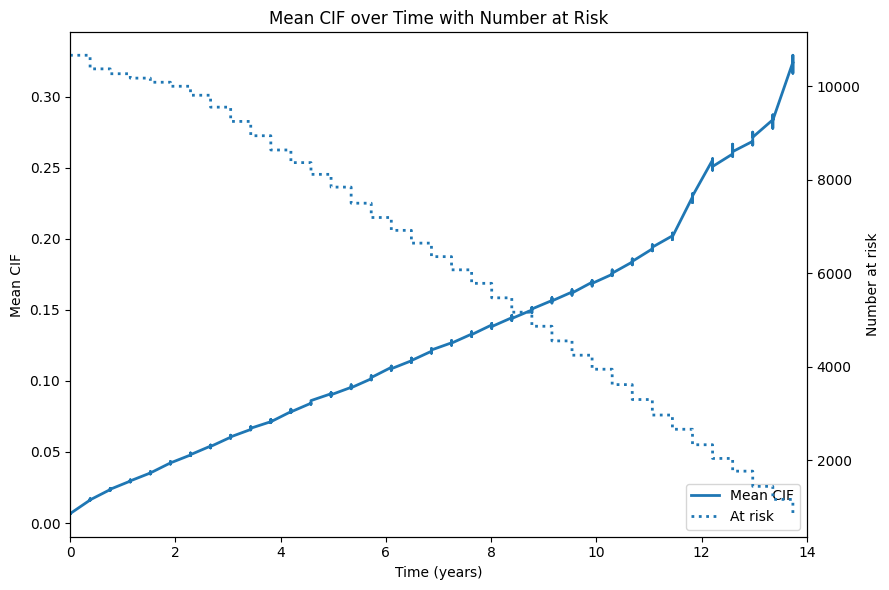

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. LOAD MEAN CIF DATA
# ==========================================
cif_df = pd.read_csv("/home/UT_shared/result/mean_cif_by_time.csv").dropna()

# Check available columns
print("Columns in CIF file:", cif_df.columns.tolist())

# Use the correct CIF column name
if "mean_cif" in cif_df.columns:
    cif_col = "mean_cif"
elif "cif" in cif_df.columns:
    cif_col = "cif"
elif "mean" in cif_df.columns:
    cif_col = "mean"
else:
    raise ValueError("Could not find CIF column. Expected one of: mean_cif, cif, mean")

cif_df["time"] = cif_df["time"].astype(float)
cif_df[cif_col] = cif_df[cif_col].astype(float)

# Sort by time
cif_df = cif_df.sort_values("time")

t_cif = cif_df["time"].values
mean_cif = cif_df[cif_col].values

# ==========================================
# 2. LOAD TEST DATA FOR NUMBER AT RISK
# ==========================================
df_test = pd.read_csv("/home/UT_shared/data/test.csv")

# Number at risk at each time point
n_at_risk = np.array([(df_test["year"] >= t).sum() for t in t_cif])

# ==========================================
# 3. OPTIONAL: RESTRICT X RANGE
# ==========================================
max_time = 14
mask = t_cif <= max_time

t_plot = t_cif[mask]
cif_plot = mean_cif[mask]
risk_plot = n_at_risk[mask]

# ==========================================
# 4. PLOT
# ==========================================
fig, ax1 = plt.subplots(figsize=(9, 6))

# Mean CIF curve
ax1.plot(t_plot, cif_plot, linewidth=2, label="Mean CIF")

ax1.set_xlabel("Time (years)")
ax1.set_ylabel("Mean CIF")
ax1.set_title("Mean CIF over Time with Number at Risk")
ax1.set_xlim(0, 14)

# Secondary axis: number at risk
ax2 = ax1.twinx()
ax2.step(t_plot, risk_plot, where="post", linewidth=2, linestyle=":", label="At risk")
ax2.set_ylabel("Number at risk")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower right")

plt.tight_layout()
plt.show()

Columns in CIF file: ['bootstrap', 'time', 'mean_cif']


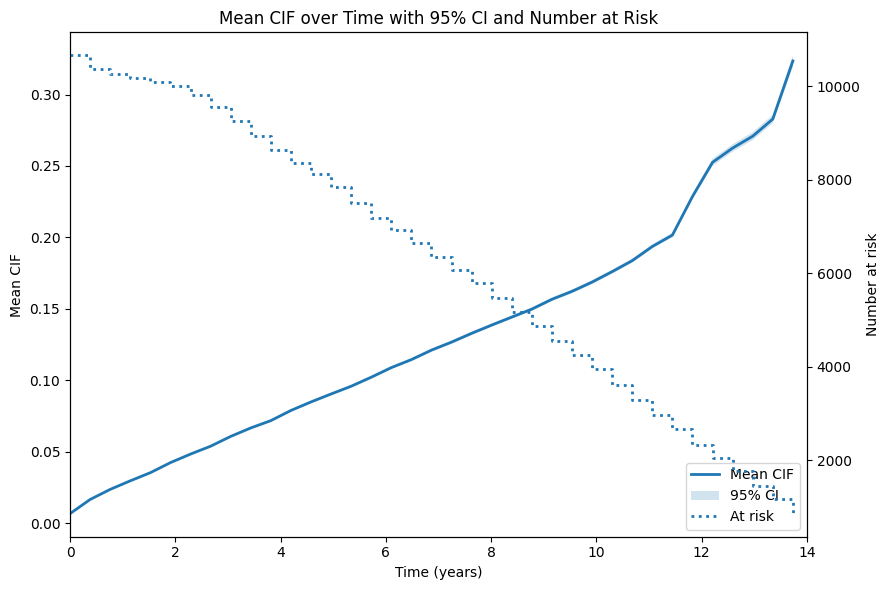

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. LOAD BOOTSTRAP CIF RESULTS
# ==========================================
cif_df = pd.read_csv("/home/UT_shared/result/mean_cif_by_time.csv").dropna()

# Expected columns: bootstrap, time, mean_cif
print("Columns in CIF file:", cif_df.columns.tolist())

cif_df["time"] = cif_df["time"].astype(float)
cif_df["mean_cif"] = cif_df["mean_cif"].astype(float)
cif_df = cif_df.sort_values(["time", "bootstrap"])

# ==========================================
# 2. COMPUTE MEAN + 95% CI ACROSS BOOTSTRAPS
# ==========================================
grouped = cif_df.groupby("time")

mean_cif = grouped["mean_cif"].mean()
lower_cif = grouped["mean_cif"].quantile(0.025)
upper_cif = grouped["mean_cif"].quantile(0.975)

t_cif = mean_cif.index.values.astype(float)
cif_mean = mean_cif.values
cif_lower = lower_cif.values
cif_upper = upper_cif.values

# Sort by time
order = np.argsort(t_cif)
t_cif = t_cif[order]
cif_mean = cif_mean[order]
cif_lower = cif_lower[order]
cif_upper = cif_upper[order]

# ==========================================
# 3. LOAD TEST DATA FOR NUMBER AT RISK
# ==========================================
df_test = pd.read_csv("/home/UT_shared/data/test.csv")

# Number at risk at each time point
n_at_risk = np.array([(df_test["year"] >= t).sum() for t in t_cif])

# ==========================================
# 4. RESTRICT X RANGE <= 14
# ==========================================
max_time = 14
mask = t_cif <= max_time

t_plot = t_cif[mask]
cif_plot = cif_mean[mask]
lower_plot = cif_lower[mask]
upper_plot = cif_upper[mask]
risk_plot = n_at_risk[mask]

# ==========================================
# 5. PLOT
# ==========================================
fig, ax1 = plt.subplots(figsize=(9, 6))

# Mean CIF + CI
ax1.plot(t_plot, cif_plot, linewidth=2, label="Mean CIF")
ax1.fill_between(t_plot, lower_plot, upper_plot, alpha=0.2, label="95% CI")

ax1.set_xlabel("Time (years)")
ax1.set_ylabel("Mean CIF")
ax1.set_title("Mean CIF over Time with 95% CI and Number at Risk")
ax1.set_xlim(0, 14)

# Secondary axis: number at risk
ax2 = ax1.twinx()
ax2.step(t_plot, risk_plot, where="post", linewidth=2, linestyle=":", label="At risk")
ax2.set_ylabel("Number at risk")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower right")

plt.tight_layout()
plt.show()

Columns: ['bootstrap', 'time', 'brier']


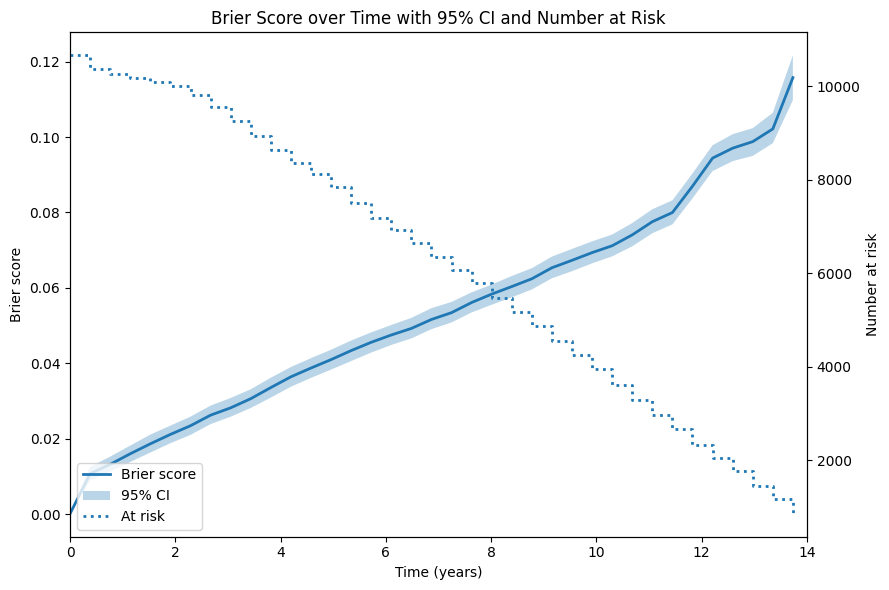

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. LOAD BOOTSTRAP BRIER RESULTS
# ==========================================
brier_df = pd.read_csv("/home/UT_shared/result/brier_by_time.csv").dropna()

print("Columns:", brier_df.columns.tolist())

# Expected: bootstrap, time, brier (or similar)
brier_col = None
for col in ["brier", "brier_score", "score"]:
    if col in brier_df.columns:
        brier_col = col
        break

if brier_col is None:
    raise ValueError("Cannot find Brier column")

brier_df["time"] = brier_df["time"].astype(float)
brier_df[brier_col] = brier_df[brier_col].astype(float)

brier_df = brier_df.sort_values(["time", "bootstrap"])

# ==========================================
# 2. COMPUTE MEAN + 95% CI
# ==========================================
grouped = brier_df.groupby("time")

mean_brier = grouped[brier_col].mean()
lower_brier = grouped[brier_col].quantile(0.025)
upper_brier = grouped[brier_col].quantile(0.975)

t_brier = mean_brier.index.values.astype(float)
brier_mean = mean_brier.values
brier_lower = lower_brier.values
brier_upper = upper_brier.values

# Sort
order = np.argsort(t_brier)
t_brier = t_brier[order]
brier_mean = brier_mean[order]
brier_lower = brier_lower[order]
brier_upper = brier_upper[order]

# ==========================================
# 3. NUMBER AT RISK
# ==========================================
df_test = pd.read_csv("/home/UT_shared/data/test.csv")

n_at_risk = np.array([(df_test["year"] >= t).sum() for t in t_brier])

# ==========================================
# 4. RESTRICT TO t <= 14
# ==========================================
max_time = 14
mask = t_brier <= max_time

t_plot = t_brier[mask]
brier_plot = brier_mean[mask]
lower_plot = brier_lower[mask]
upper_plot = brier_upper[mask]
risk_plot = n_at_risk[mask]

# ==========================================
# 5. PLOT
# ==========================================
fig, ax1 = plt.subplots(figsize=(9, 6))

# Brier curve (lower is better!)
ax1.plot(t_plot, brier_plot, linewidth=2, label="Brier score")
ax1.fill_between(t_plot, lower_plot, upper_plot, alpha=0.3, label="95% CI")

ax1.set_xlabel("Time (years)")
ax1.set_ylabel("Brier score")
ax1.set_title("Brier Score over Time with 95% CI and Number at Risk")
ax1.set_xlim(0, 14)

# Secondary axis: number at risk
ax2 = ax1.twinx()
ax2.step(t_plot, risk_plot, where="post", linestyle=":", linewidth=2, label="At risk")
ax2.set_ylabel("Number at risk")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower left")

plt.tight_layout()
plt.show()

Columns: ['bootstrap', 'time', 'c_index']


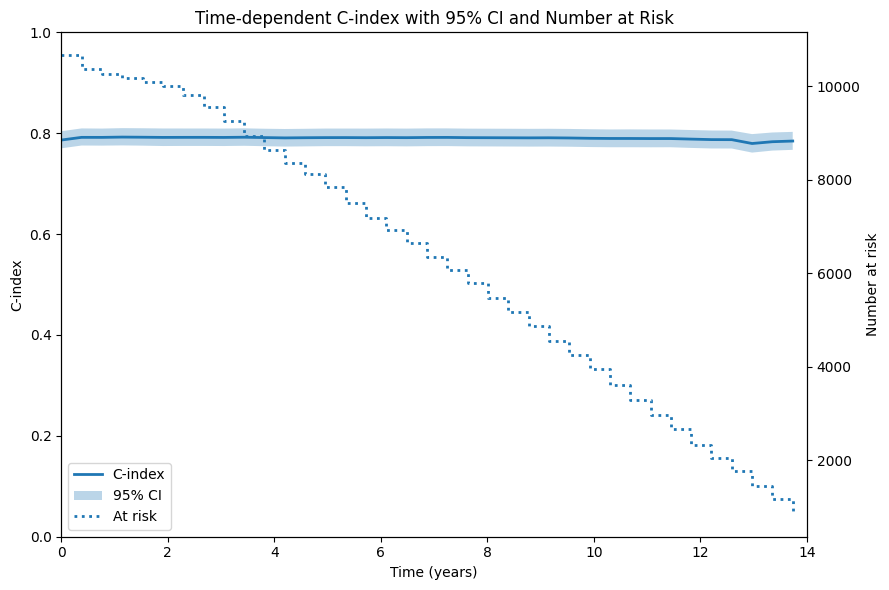

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. LOAD BOOTSTRAP C-INDEX RESULTS
# ==========================================
cindex_df = pd.read_csv("/home/UT_shared/result/boot_tab_deephit_cindex_dur_40.csv").dropna()

print("Columns:", cindex_df.columns.tolist())

if "c_index" not in cindex_df.columns:
    raise ValueError("Cannot find 'c_index' column in cindex_by_time.csv")

cindex_df["time"] = cindex_df["time"].astype(float)
cindex_df["c_index"] = cindex_df["c_index"].astype(float)

cindex_df = cindex_df.sort_values(["time", "bootstrap"])

# ==========================================
# 2. COMPUTE MEAN + 95% CI
# ==========================================
grouped = cindex_df.groupby("time")

mean_c = grouped["c_index"].mean()
lower_c = grouped["c_index"].quantile(0.025)
upper_c = grouped["c_index"].quantile(0.975)

t_c = mean_c.index.values.astype(float)
c_mean = mean_c.values
c_lower = lower_c.values
c_upper = upper_c.values

# Sort
order = np.argsort(t_c)
t_c = t_c[order]
c_mean = c_mean[order]
c_lower = c_lower[order]
c_upper = c_upper[order]

# ==========================================
# 3. NUMBER AT RISK
# ==========================================
df_test = pd.read_csv("/home/UT_shared/data/test.csv")

n_at_risk = np.array([(df_test["year"] >= t).sum() for t in t_c])

# ==========================================
# 4. RESTRICT TO t <= 14
# ==========================================
max_time = 14
mask = t_c <= max_time

t_plot = t_c[mask]
c_plot = c_mean[mask]
lower_plot = c_lower[mask]
upper_plot = c_upper[mask]
risk_plot = n_at_risk[mask]

# ==========================================
# 5. PLOT
# ==========================================
fig, ax1 = plt.subplots(figsize=(9, 6))

# C-index curve (higher is better)
ax1.plot(t_plot, c_plot, linewidth=2, label="C-index")
ax1.fill_between(t_plot, lower_plot, upper_plot, alpha=0.3, label="95% CI")

ax1.set_xlabel("Time (years)")
ax1.set_ylabel("C-index")
ax1.set_title("Time-dependent C-index with 95% CI and Number at Risk")
ax1.set_xlim(0, 14)
ax1.set_ylim(0, 1)

# Secondary axis: number at risk
ax2 = ax1.twinx()
ax2.step(t_plot, risk_plot, where="post", linestyle=":", linewidth=2, label="At risk")
ax2.set_ylabel("Number at risk")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower left")

plt.tight_layout()
plt.show()